In [3]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style="darkgrid")


### Load Dataset (.arff format)

In [ ]:
file_path = r"B:\action-leaning\ml"

data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)

# Decode object columns
for col in df.select_dtypes(include=[object]).columns:
    try:
        df[col] = df[col].str.decode('utf-8')
    except:
        pass

df.head()


,SRC_ADD,DES_ADD,PKT_ID,FROM_NODE,TO_NODE,PKT_TYPE,PKT_SIZE,FLAGS,FID,SEQ_NUMBER,...,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED,PKT_CLASS
0,3.00,24.30,389693.0,21.0,23.0,tcp,1540.0,-------,4.0,11339.0,...,328.240918,505490.0,1540.0,0.236321,0.0,35.519662,35.550032,1.000000,50.021920,Normal
1,15.00,24.15,201196.0,23.0,24.0,tcp,1540.0,-------,16.0,6274.0,...,328.205808,505437.0,1540.0,0.236337,0.0,20.156478,20.186848,1.000000,50.030211,Normal
2,24.15,15.00,61905.0,23.0,22.0,ack,55.0,-------,16.0,1930.0,...,328.206042,18051.3,55.0,0.008441,0.0,7.039952,7.069962,1.030045,50.060221,UDP-Flood
3,24.90,9.00,443135.0,23.0,21.0,ack,55.0,-------,10.0,12670.0,...,328.064183,18043.5,55.0,0.008437,0.0,39.617967,39.647976,1.030058,50.060098,Normal
4,24.80,8.00,157335.0,23.0,21.0,ack,55.0,-------,9.0,4901.0,...,328.113525,18046.2,55.0,0.008438,0.0,16.029803,16.059813,1.030054,50.061864,Normal


### Check for Nulls and Duplicates

In [5]:
print("Null values per column:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Null values per column:
SRC_ADD             0
DES_ADD             0
PKT_ID              0
FROM_NODE           0
TO_NODE             0
PKT_TYPE            0
PKT_SIZE            0
FLAGS               0
FID                 0
SEQ_NUMBER          0
NUMBER_OF_PKT       0
NUMBER_OF_BYTE      0
NODE_NAME_FROM      0
NODE_NAME_TO        0
PKT_IN              0
PKT_OUT             0
PKT_R               0
PKT_DELAY_NODE      0
PKT_RATE            0
BYTE_RATE           0
PKT_AVG_SIZE        0
UTILIZATION         0
PKT_DELAY           0
PKT_SEND_TIME       0
PKT_RESEVED_TIME    0
FIRST_PKT_SENT      0
LAST_PKT_RESEVED    0
PKT_CLASS           0
dtype: int64

Duplicates: 0


### Encode Labels (0 = Normal, 1 = Attack)

In [6]:
print("Unique values in PKT_CLASS:", df['PKT_CLASS'].unique())

df['label'] = df['PKT_CLASS'].apply(lambda x: 0 if x.lower() == 'normal' else 1)
print("Label distribution:\n", df['label'].value_counts())


Unique values in PKT_CLASS: ['Normal' 'UDP-Flood' 'Smurf' 'SIDDOS' 'HTTP-FLOOD']
Label distribution:
 label
0    1935959
1     224709
Name: count, dtype: int64


### Class Distribution Plot

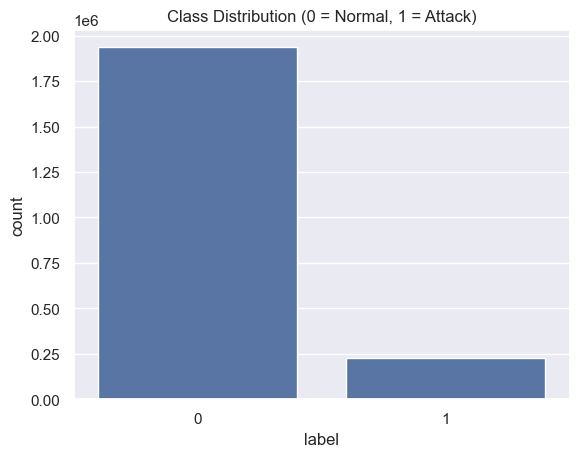

In [7]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Attack)")
plt.show()


### Feature Engineering

In [8]:
# Convert times to numeric
df['PKT_SEND_TIME'] = pd.to_numeric(df['PKT_SEND_TIME'], errors='coerce')
df['PKT_RESEVED_TIME'] = pd.to_numeric(df['PKT_RESEVED_TIME'], errors='coerce')

# New feature: Flow duration
df['FLOW_DURATION'] = df['PKT_RESEVED_TIME'] - df['PKT_SEND_TIME']

# New feature: Average byte per packet
df['AVG_BYTES_PER_PKT'] = df['NUMBER_OF_BYTE'] / (df['NUMBER_OF_PKT'] + 1e-6)

df[['FLOW_DURATION', 'AVG_BYTES_PER_PKT']].describe()


,FLOW_DURATION,AVG_BYTES_PER_PKT
count,2.160668e+06,2.160668e+06
mean,3.282350e-02,1.049439e+03
std,1.368119e-02,3.273088e+03
min,-1.144640e-01,5.499999e+01
25%,3.001000e-02,5.500000e+01
50%,3.037000e-02,1.000000e+03
75%,3.095000e-02,1.539998e+03
max,1.536800e-01,6.553524e+04


### Drop Unused Columns and Prepare Dataset

In [12]:
# Drop string-type and identifier columns
string_cols = df.select_dtypes(include='object').columns.tolist()
cols_to_drop = ['PKT_CLASS', 'label', 'SRC_ADD', 'DES_ADD', 'NODE_NAME_FROM', 'NODE_NAME_TO'] + string_cols

X = df.drop(columns=list(set(cols_to_drop)))  # drop all text columns


### Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (1728534, 23), Test size: (432134, 23)


### Normalize Features

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Save Processed Datasets

In [15]:
# Save as CSV for use in ML model training
pd.DataFrame(X_train_scaled).to_csv("X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled).to_csv("X_test_scaled.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
print("Processed datasets saved.")


Processed datasets saved.
